# DeepScaleR 10k — pass@32 distribution by difficulty quartile

Plot the number of prompts at each pass rate for
[`mnoukhov/deepscaler-10k-qwen3-4b-base-32samples-quartiles`](https://huggingface.co/datasets/mnoukhov/deepscaler-10k-qwen3-4b-base-32samples-quartiles),
with vertical lines marking the quartile splits.

The dataset was split into 4 difficulty quartiles by sorting on `pass_count`
(highest pass rate / easiest first), so each quartile holds ~1/4 of the prompts.
The combined `train` split carries a `dataset` column (e.g. `math_deepscaler_quartile0`)
that records which quartile each prompt belongs to.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
from datasets import load_dataset

DATASET_REPO = "mnoukhov/deepscaler-10k-qwen3-4b-base-32samples-quartiles"
SPLIT = "train"  # combined split holding all quartiles


def extract_pass_count(row: pd.Series) -> int:
    """Mirror create_gsm8k_pass_rate_quartiles.extract_pass_count."""
    pass_count = row.get("pass_count")
    if pd.notna(pass_count):
        return int(pass_count)
    pass_rate = row.get("pass_rate")
    if isinstance(pass_rate, str) and "/" in pass_rate:
        return int(pass_rate.split("/", 1)[0].strip())
    raise ValueError("Row is missing pass_count and parseable pass_rate")


df = load_dataset(DATASET_REPO, split=SPLIT).to_pandas()
df["pass_count"] = df.apply(extract_pass_count, axis=1)

# num_samples is constant (32) but read it from the data when available.
num_samples = int(df["num_samples"].iloc[0]) if "num_samples" in df.columns else 32
df["quartile"] = df["dataset"].str.extract(r"quartile(\d+)").astype(int)

print(f"Loaded {len(df)} prompts, num_samples={num_samples}")
print(df.groupby("quartile")["pass_count"].agg(["count", "min", "max"]))

Loaded 10000 prompts, num_samples=32
          count  min  max
quartile                 
0          2500   16   32
1          2500    6   16
2          2500    1    6
3          2500    0    1


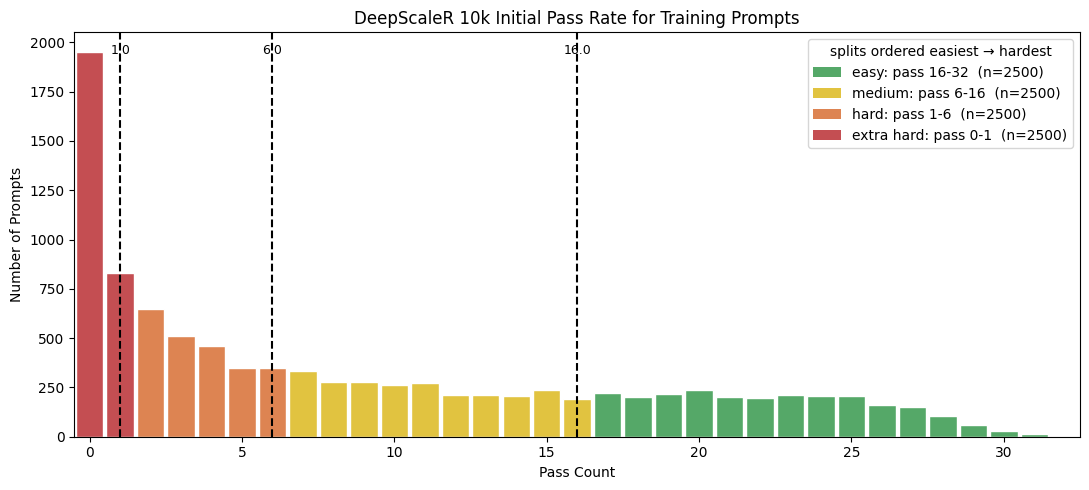

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pass_values = np.arange(num_samples + 1)
counts = df["pass_count"].value_counts().reindex(pass_values, fill_value=0).sort_index()

# For each pass_count value, the majority quartile (used to colour its bar).
# Quartile 0 = highest pass_count (easiest); a value may straddle a boundary.
maj_quartile = (
    df.groupby("pass_count")["quartile"]
    .agg(lambda s: s.mode().iloc[0])
    .reindex(pass_values)
)

# Quartile boundaries: midpoint between the min pass_count of the harder
# quartile and the max pass_count of the easier neighbouring quartile.
qstats = df.groupby("quartile")["pass_count"].agg(["min", "max", "count"])
boundaries = [
    (qstats.loc[q, "min"] + qstats.loc[q + 1, "max"]) / 2.0
    for q in range(qstats.index.max())
]

split_names = ["easy", "medium", "hard", "extra hard"]  # easiest -> hardest
colors = ["#55A868", "#E1C340", "#DD8452", "#C44E52"]  # green, yellow, orange, red
bar_colors = [
    colors[int(q) % len(colors)] if pd.notna(q) else "#cccccc" for q in maj_quartile
]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(pass_values, counts.values, width=0.9, color=bar_colors, edgecolor="white")

ymax = ax.get_ylim()[1]
for b in boundaries:
    ax.axvline(b, color="black", linestyle="--", linewidth=1.5)
    ax.text(b, ymax * 0.97, f"{b:.1f}", ha="center", va="top", fontsize=9)

legend_handles = [
    Patch(
        facecolor=colors[q % len(colors)],
        label=f"{split_names[q]}: pass {qstats.loc[q, 'min']}-{qstats.loc[q, 'max']}  (n={qstats.loc[q, 'count']})",
    )
    for q in sorted(df["quartile"].unique())
]
ax.legend(handles=legend_handles, title="splits ordered easiest → hardest")

ax.set_xlabel("Pass Count")
ax.set_ylabel("Number of Prompts")
ax.set_title("DeepScaleR 10k Initial Pass Rate for Training Prompts")
ax.set_xlim(-0.5, num_samples + 0.5)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "deepscaler_pass_rate_quartiles.pdf", bbox_inches="tight")
plt.show()